# **Résolution du Task 1 Analyste Quantitatif chez JP Morgan Corporation**

In [1]:
import os
cwd = os.getcwd()
print("Current working directory: {0}".format(cwd))

#Copy the filepath
os.chdir("/home/angelo-btma/Bureau/Forage/Mission1")


Current working directory: /home/angelo-btma/Bureau/Forage/Mission1


### **Let's jump to task 1**

In [2]:
# Import des librairies phares
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

In [3]:
date_time = ["10-2020","11-2020","12-2020"]
date_time = pd.to_datetime(date_time)
data = [1, 2, 3]

/tmp/ipykernel_31744/504223048.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_time = pd.to_datetime(date_time)


In [4]:
df = pd.read_csv("Nat_Gas.csv", parse_dates=["Dates"])
df

/tmp/ipykernel_31744/2155408537.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("Nat_Gas.csv", parse_dates=["Dates"])


,Dates,Prices
0,2020-10-31,10.10
1,2020-11-30,10.30
2,2020-12-31,11.00
3,2021-01-31,10.90
4,2021-02-28,10.90
5,2021-03-31,10.90
6,2021-04-30,10.40
7,2021-05-31,9.84
8,2021-06-30,10.00
9,2021-07-31,10.10


In [5]:
prices = df["Prices"].values
dates = df["Dates"].values

In [20]:
print(dates)

['2020-10-31T00:00:00.000000' '2020-11-30T00:00:00.000000'
 '2020-12-31T00:00:00.000000' '2021-01-31T00:00:00.000000'
 '2021-02-28T00:00:00.000000' '2021-03-31T00:00:00.000000'
 '2021-04-30T00:00:00.000000' '2021-05-31T00:00:00.000000'
 '2021-06-30T00:00:00.000000' '2021-07-31T00:00:00.000000'
 '2021-08-31T00:00:00.000000' '2021-09-30T00:00:00.000000'
 '2021-10-31T00:00:00.000000' '2021-11-30T00:00:00.000000'
 '2021-12-31T00:00:00.000000' '2022-01-31T00:00:00.000000'
 '2022-02-28T00:00:00.000000' '2022-03-31T00:00:00.000000'
 '2022-04-30T00:00:00.000000' '2022-05-31T00:00:00.000000'
 '2022-06-30T00:00:00.000000' '2022-07-31T00:00:00.000000'
 '2022-08-31T00:00:00.000000' '2022-09-30T00:00:00.000000'
 '2022-10-31T00:00:00.000000' '2022-11-30T00:00:00.000000'
 '2022-12-31T00:00:00.000000' '2023-01-31T00:00:00.000000'
 '2023-02-28T00:00:00.000000' '2023-03-31T00:00:00.000000'
 '2023-04-30T00:00:00.000000' '2023-05-31T00:00:00.000000'
 '2023-06-30T00:00:00.000000' '2023-07-31T00:00:00.00000

/tmp/ipykernel_31744/4137096953.py:5: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(dates, prices, "-")


<Figure size 1400x800 with 0 Axes>

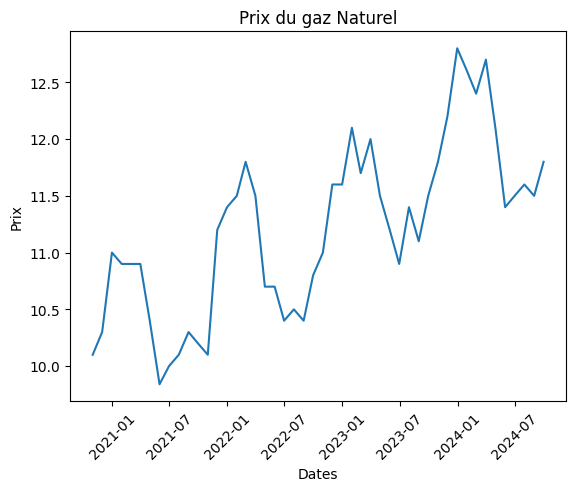

In [6]:
# Plot Prices against dates
plt.figure(figsize=(14, 8))
fig, ax = plt.subplots()

ax.plot_date(dates, prices, "-")
ax.set_xlabel("Dates")
ax.set_ylabel("Prix")
ax.set_title("Prix du gaz Naturel")
ax.tick_params(axis = "x", rotation = 45)

plt.show()


D'après le graphique, on constate que les prix ont une fréquence naturelle d'environ un an, mais une tendance à la hausse. On peut effectuer une régression linéaire pour obtenir la tendance, puis ajuster une fonction sinus à la variation annuelle.

Il nous faut d'abord les dates exprimées en jours depuis le début,pour faciliter l'interpolation ultérieure.

In [7]:
start_date = date(2020, 10, 31)
end_date = date(2024, 9, 30)
months = []
year = start_date.year
month = start_date.month + 1
while True:
    current = date(year, month, 1) + timedelta(days=-1)
    months.append(current)
    if current.month == end_date.month and current.year == end_date.year:
       break
    else:
       month = ((month + 1) % 12) or 12
       if month == 1:
           year += 1

days_from_start = [(day - start_date ).days for day in months]

Simple regression for the trend will fit to a model $y = Ax + B$. The estimator for the slope is given by $\hat{A} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$, and that for the intercept by $\hat{B} = \bar{y} - \hat{A} \bar{x}$.

In [8]:
def simple_regression(x, y):
    xbar = np.mean(x)
    ybar = np.mean(y)
    slope = np.sum((x-xbar)*(y-ybar))/np.sum((x-xbar)**2)
    intercept = ybar-slope*xbar
    return slope, intercept

In [9]:
time = np.array(days_from_start)
slope, intercept = simple_regression(time, prices)

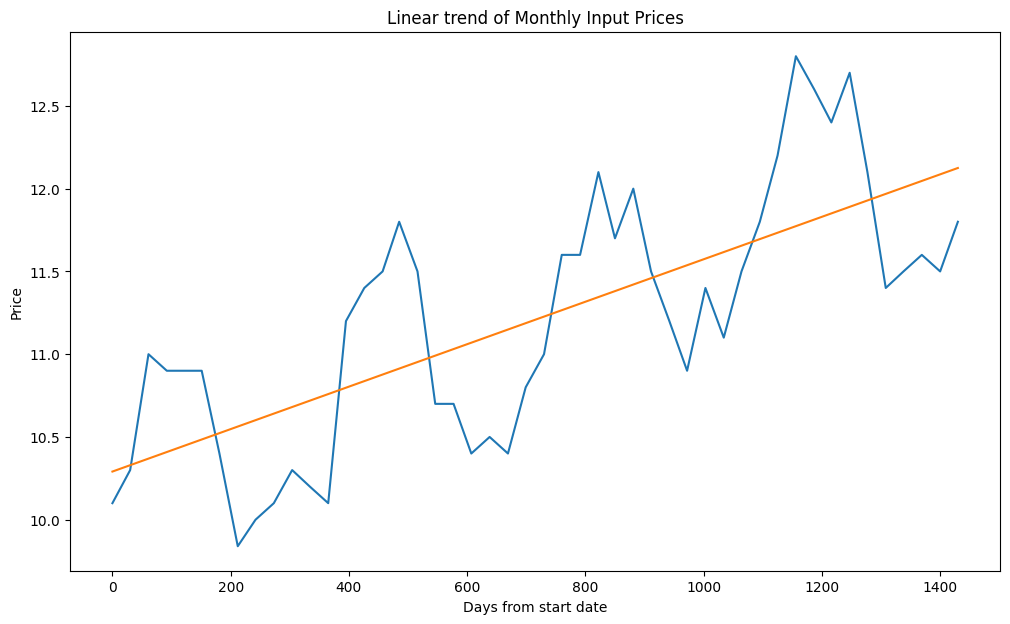

0.001282373598760221 10.29104112595228


In [10]:
# Plot linear trend
plt.figure(figsize=(12, 7))
plt.plot(time, prices)
plt.plot(time, time*slope + intercept)
plt.xlabel("Days from start date")
plt.ylabel("Price")
plt.title("Linear trend of Monthly Input Prices")
plt.show()
print(slope, intercept)

From this plot we see the linear trend has been captured. Now to fit the intra-year variation. Given that natural gas is used more in winter, and less in summer, we can guess the frequency of the price movements to be about a year, or 12 months. Therefore we have a model $y = A \sin(kt + z)$ with a known frequency. Rewriting $y = A \cos(z) \sin(kt) + A \sin(z) \cos(kt)$, we can use bilinear regression, with no intercept, to solve for $u = A \cos(z)$, $w = A \sin(z)$.

In [11]:
sin_prices = prices - (slope*time + intercept)
sin_time = np.sin(time*2*np.pi/(365))
cos_time = np.cos(time*2*np.pi/(365))

In [12]:
def bilinear_regression(y, x1, x2):
    #La régression bilinéaire sans ordonnée à l'origine revient à projeter sur les vecteurs x
    slope1 = np.sum(y*x1)/np.sum(x1**2)
    slope2 = np.sum(y*x2)/np.sum(x2**2)
    return(slope1, slope2)


In [13]:
slope1, slope2 = bilinear_regression(sin_prices, sin_time, cos_time)
slope1, slope2

(np.float64(0.6645033338185616), np.float64(-0.04140626453562663))

We now recover the original amplitude and phase shift as $A = \sqrt{\text{slope1}^2 + \text{slope2}^2}$, $z = \tan^{-1}(\text{slope2}/\text{slope1})$.

In [14]:
amplitude = np.sqrt(slope1**2 + slope2*2)
shift = np.arctan2(slope2, slope1)


Text(0.5, 1.0, "Représenter graphiquement l'estimation lissée des prix mensuelles")

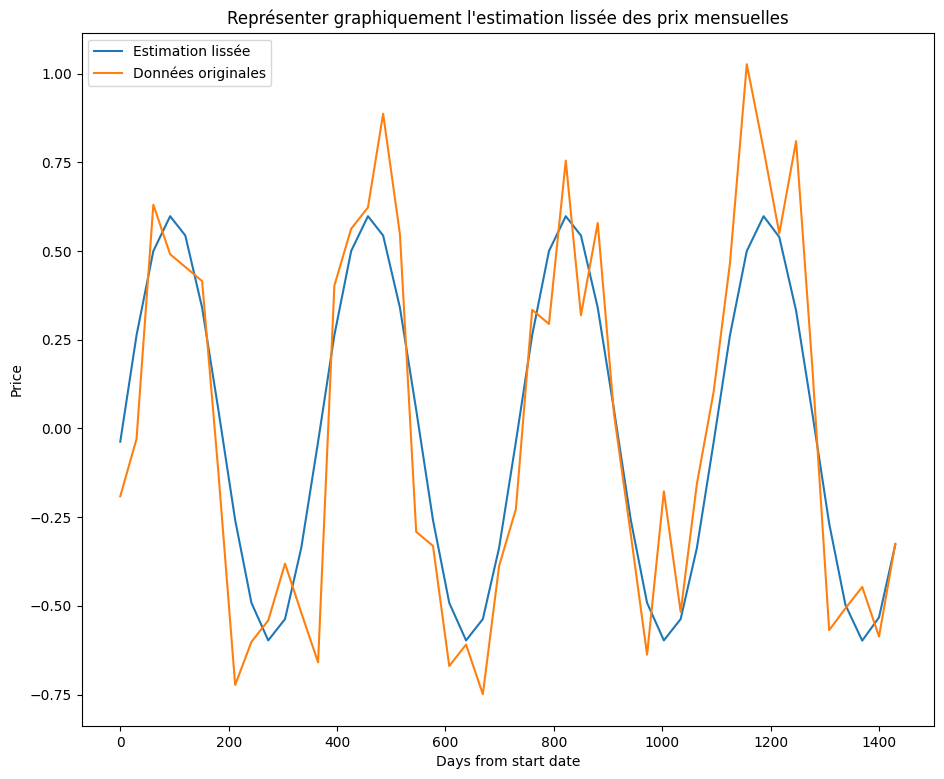

In [18]:
#Représenter graphiquement l'estimation lissée de l'ensemble de données complet
plt.figure(figsize=(11,9))
plt.plot(time, amplitude*np.sin(time*2*np.pi/(365)+shift))
plt.plot(time, sin_prices)
# Légende pour chacune des courbes
plt.legend(["Estimation lissée", "Données originales"])
plt.xlabel("Days from start date")
plt.ylabel("Price")
plt.title("Représenter graphiquement l'estimation lissée des prix mensuelles")

In [22]:
# Define the interpolation/extrapolation function
def interpolate(date):
    days = (date-pd.Timestamp(start_date)).days
    if days in days_from_start:
        # Exact match found in the data
        return prices[days_from_start.index(days)]
    else:
        #Interpolate/extrapolate using the sin/cos model
        return amplitude*np.sin(days*2*np.pi/365 + shift) + days*slope + intercept

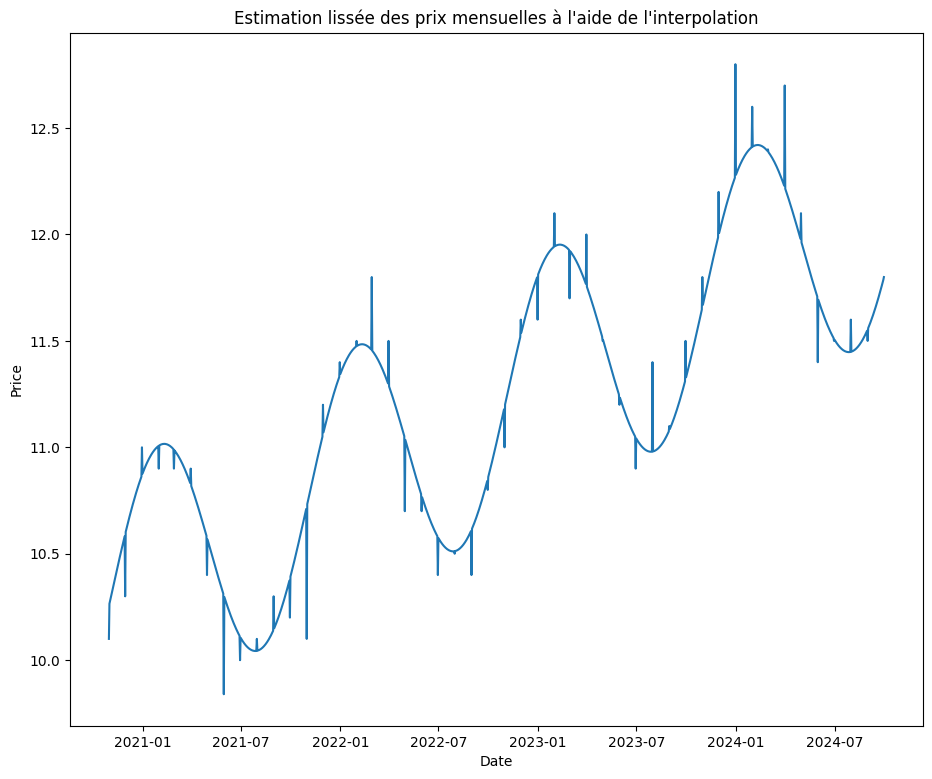

In [25]:
# Create a range of continuous dates from start date to end date
continious_dates = pd.date_range(start= start_date, end= end_date, freq='D')
# Tracer l'estimation lissée de l'ensemble des données à l'aide de l'interpolation
#Design
plt.figure(figsize=(11,9))
plt.plot(continious_dates, [interpolate(days) for days in continious_dates], label='Smoothed Estimate')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Estimation lissée des prix mensuelles à l'aide de l'interpolation")
plt.show()

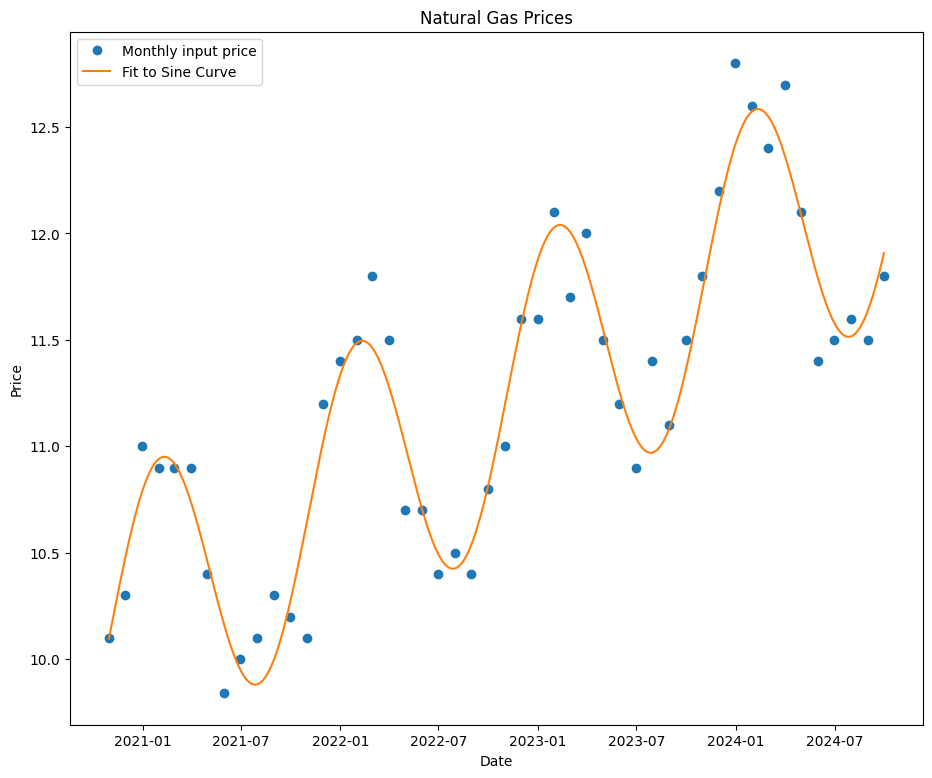

In [27]:
# Ajuster les prix mensuels des inputs à la courbe sinusoïdale
x = np.array(days_from_start)
y = np.array(prices)
fit_amplitude = np.sqrt(slope1**2+slope2**2)
fit_shift = np.arctan2(slope2, slope1)
fit_slope, fit_intercept = simple_regression(x, y-fit_amplitude*np.sin(x*2*np.pi/365 + fit_shift))
plt.figure(figsize=(11, 9))
plt.plot(dates, y, 'o', label = "Monthly input price")
plt.plot(continious_dates, fit_amplitude*np.sin((continious_dates - pd.Timestamp(start_date)).days * 2* np.pi / 365 + fit_shift) + (continious_dates -pd.Timestamp(start_date)).days * fit_slope + fit_intercept,label='Fit to Sine Curve')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices')
plt.legend()
plt.show()
